# Projet Prédiction du Prix des Logements (House Prices)
## Notebook d'Exploration Approfondie, Dictionnaire des Données et Traitement des Valeurs Nulles

Bienvenue dans ce notebook d'analyse exploratoire du jeu de données **House Prices** (ville d'Ames, Iowa).

### Objectifs de ce notebook :
1. **Comprendre chaque variable** : Un dictionnaire détaillé avec la signification et des exemples réels de valeurs pour toutes les colonnes.
2. **Visualiser les tendances clés** : Des graphiques clairs pour observer la distribution des prix, les corrélations majeures, l'impact des quartiers, des surfaces et des équipements.
3. **Diagnostiquer toutes les valeurs manquantes** : Identifier pourquoi certaines colonnes ont des cases vides (très souvent, un vide signifie simplement l'absence d'un équipement, comme l'absence de piscine ou de garage).
4. **Stratégie complète de nettoyage et d'imputation** : Corriger et remplacer proprement toutes les valeurs nulles pour conserver l'ensemble des 80 colonnes pour l'entraînement futur de nos modèles (Régression Linéaire, Ridge, Arbres, Random Forest, Gradient Boosting, etc.).

> **Note importante** : Toutes les explications de ce notebook sont rédigées en français simple et direct, sans formules mathématiques complexes.


## 1. Importation des Bibliothèques et Chargement des Données

Nous utilisons :
- **pandas** pour la manipulation des tables de données.
- **numpy** pour les calculs numériques et les transformations logarithmiques.
- **matplotlib** et **seaborn** pour générer des visualisations graphiques soignées et parlantes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration des graphiques et des alertes
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Bibliothèques prêtes pour l'analyse !")


Bibliothèques prêtes pour l'analyse !


### Chargement du fichier `House_Prices.csv`
Affichons la taille de la table et un premier aperçu des 5 premières lignes.


In [2]:
df = pd.read_csv('House_Prices.csv')
print(f"Dimensions du jeu de données : {df.shape[0]} maisons (lignes) et {df.shape[1]} caractéristiques (colonnes).")
df.head(5)


Dimensions du jeu de données : 2919 maisons (lignes) et 81 caractéristiques (colonnes).


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


## 2. Dictionnaire Complet des Données et Exemples de Valeurs

Le fichier contient **81 colonnes au total** :
- **1 identifiant** : `Id` (numéro unique de la maison).
- **1 variable cible** : `SalePrice` (prix de vente en dollars).
- **79 caractéristiques explicatives** réparties en grandes familles immobilières.

Pour vous permettre d'avoir une vision claire et immédiate, voici le détail de chaque champ avec sa signification d'après `data_description.txt` et des exemples concrets tirés directement de notre jeu de données.


In [ ]:
# Création d'un dictionnaire enrichi des colonnes avec leur rôle et famille
colonnes_descriptions = {
    # Famille 1 : Identification & Vente
    'Id': ('Identification', 'Identifiant unique de la transaction (à exclure du modèle pour éviter la mémorisation)'),
    'MoSold': ('Vente', 'Mois de la vente (de 1 = Janvier à 12 = Décembre)'),
    'YrSold': ('Vente', 'Année de la vente (de 2006 à 2010)'),
    'SaleType': ('Vente', 'Type d\'acte de vente (WD = Contrat standard, New = Vente neuve, COD = Officier de justice...)'),
    'SaleCondition': ('Vente', 'Condition de la vente (Normal, Abnorml = vente forcée/succession, Partial = maison pas finie...)'),
    'SalePrice': ('CIBLE', 'Prix de vente final du logement en dollars (variable cible à prédire)'),

    # Famille 2 : Emplacement, Terrain & Zonage
    'MSZoning': ('Emplacement', 'Classement de zonage (RL = Résidentiel faible densité, RM = moyenne densité, C = Commercial...)'),
    'LotFrontage': ('Terrain', 'Longueur de façade du terrain donnant sur la rue (en pieds linéaires)'),
    'LotArea': ('Terrain', 'Superficie totale de la parcelle de terrain (en pieds carrés)'),
    'Street': ('Terrain', 'Type de voie d\'accès à la propriété (Pave = goudronnée, Grvl = gravier)'),
    'Alley': ('Terrain', 'Type d\'allée secondaire (Pave, Grvl, NA = pas d\'accès allée)'),
    'LotShape': ('Terrain', 'Forme géométrique du terrain (Reg = régulier/rectangle, IR1, IR2, IR3 = irrégulier)'),
    'LandContour': ('Terrain', 'Nivellement du terrain (Lvl = plat, Bnk = surélevé/talus, HLS = colline, Low = cuvette)'),
    'Utilities': ('Terrain', 'Services publics raccordés (AllPub = Eau, Gaz, Électricité, Tout-à-l\'égout)'),
    'LotConfig': ('Terrain', 'Configuration de la parcelle (Inside = au milieu de la rue, Corner = angle de rue, CulDSac = impasse)'),
    'LandSlope': ('Terrain', 'Pente du terrain (Gtl = pente douce, Mod = pente modérée, Sev = forte pente)'),
    'Neighborhood': ('Emplacement', 'Nom du quartier d\'Ames (25 quartiers différents, ex: College Creek, Old Town, Northridge...)'),
    'Condition1': ('Emplacement', 'Proximité d\'un axe de transport (Norm = normal, Feedr = rue passante, Artery = grand axe, RRA = voie ferrée...)'),
    'Condition2': ('Emplacement', 'Deuxième proximité de transport si plus d\'une condition est présente'),

    # Famille 3 : Structure du Bâtiment & Matériaux Extérieurs
    'MSSubClass': ('Structure', 'Type architectural et étage du logement (20 = 1 étage récent, 60 = 2 étages récent, 50 = 1.5 étage ancien...)'),
    'BldgType': ('Structure', 'Type de bâtiment (1Fam = Maison individuelle, Duplex = Bifamille, TwnhsE = Maison de ville d\'angle...)'),
    'HouseStyle': ('Structure', 'Style de logement (1Story, 2Story, 1.5Fin, SFoyer, SLvl = demi-niveaux)'),
    'OverallQual': ('Qualité', 'Note globale des matériaux et finitions de la maison (de 1 = Très mauvais à 10 = Très excellent)'),
    'OverallCond': ('Qualité', 'Note de l\'état général d\'entretien du bien (de 1 = Mauvais état à 10 = Excellent état)'),
    'YearBuilt': ('Historique', 'Année de construction d\'origine de la maison (de 1872 à 2010)'),
    'YearRemodAdd': ('Historique', 'Année de dernière rénovation ou agrandissement (égale à YearBuilt si aucune rénovation)'),
    'RoofStyle': ('Toiture', 'Forme du toit (Gable = deux pans, Hip = quatre pans, Mansard, Flat = toit plat...)'),
    'RoofMatl': ('Toiture', 'Matériau de couverture du toit (CompShg = bardeaux composites standard, Tar&Grv, Wood...)'),
    'Exterior1st': ('Extérieur', 'Matériau du revêtement extérieur principal (VinylSd = vinyle, MetalSd, Wd Sdng = bois, BrkFace = brique...)'),
    'Exterior2nd': ('Extérieur', 'Deuxième matériau du revêtement extérieur si composite'),
    'MasVnrType': ('Extérieur', 'Type de placage de maçonnerie (BrkFace = brique, Stone = pierre, None = aucun)'),
    'MasVnrArea': ('Extérieur', 'Surface du placage de maçonnerie en pieds carrés'),
    'ExterQual': ('Qualité', 'Qualité des matériaux extérieurs (Ex = Excellent, Gd = Bon, TA = Moyen, Fa = Faible)'),
    'ExterCond': ('Qualité', 'État actuel des matériaux extérieurs (Ex, Gd, TA, Fa, Po = Mauvais)'),
    'Foundation': ('Structure', 'Type de fondation (PConc = Béton coulé, CBlock = Parpaings, BrkTil = Brique et tuile, Slab = Dalle)'),

    # Famille 4 : Sous-sol (Basement)
    'BsmtQual': ('Sous-sol', 'Hauteur sous plafond du sous-sol (Ex = 100+ pouces, Gd = 90-99, TA = 80-89, Fa = 70-79, NA = pas de sous-sol)'),
    'BsmtCond': ('Sous-sol', 'État général du sous-sol (humidité, fissures. Ex, Gd, TA, Fa, NA = pas de sous-sol)'),
    'BsmtExposure': ('Sous-sol', 'Niveau d\'ouverture vers l\'extérieur (Gd = baies vitrées, Av, Mn, No = fermé, NA = pas de sous-sol)'),
    'BsmtFinType1': ('Sous-sol', 'Qualité d\'aménagement de la zone principale du sous-sol (GLQ = aménagé confort, ALQ, BLQ, Unf = non aménagé)'),
    'BsmtFinSF1': ('Sous-sol', 'Surface aménagée de type 1 dans le sous-sol (en pieds carrés)'),
    'BsmtFinType2': ('Sous-sol', 'Qualité d\'aménagement de la seconde zone du sous-sol si applicable'),
    'BsmtFinSF2': ('Sous-sol', 'Surface aménagée de type 2 dans le sous-sol (en pieds carrés)'),
    'BsmtUnfSF': ('Sous-sol', 'Surface non aménagée / brute du sous-sol (en pieds carrés)'),
    'TotalBsmtSF': ('Sous-sol', 'Superficie totale du sous-sol (en pieds carrés)'),

    # Famille 5 : Chauffage, Électricité & Climatisation
    'Heating': ('Confort', 'Type de système de chauffage (GasA = air pulsé au gaz, GasW = eau chaude au gaz, Grav = gravité...)'),
    'HeatingQC': ('Confort', 'Qualité et état du chauffage (Ex = Excellent, Gd = Bon, TA = Moyen, Fa, Po)'),
    'CentralAir': ('Confort', 'Présence de la climatisation centrale (Y = Oui, N = Non)'),
    'Electrical': ('Confort', 'Système électrique (SBrkr = disjoncteurs standards, FuseA = fusibles 60A récents, FuseF/FuseP = anciens fusibles)'),

    # Famille 6 : Espaces de Vie Hors Sous-sol
    '1stFlrSF': ('Surfaces', 'Surface habitable du rez-de-chaussée (en pieds carrés)'),
    '2ndFlrSF': ('Surfaces', 'Surface habitable du premier étage (en pieds carrés)'),
    'LowQualFinSF': ('Surfaces', 'Surface de finition de faible qualité sur l\'ensemble des étages (en pieds carrés)'),
    'GrLivArea': ('Surfaces', 'Surface habitable totale au-dessus du niveau du sol (hors sous-sol, en pieds carrés)'),

    # Famille 7 : Pièces Intérieures & Commodités
    'BsmtFullBath': ('Pièces', 'Nombre de salles de bain complètes situées au sous-sol'),
    'BsmtHalfBath': ('Pièces', 'Nombre de demi-salles d\'eau situées au sous-sol'),
    'FullBath': ('Pièces', 'Nombre de salles de bain complètes au-dessus du sol'),
    'HalfBath': ('Pièces', 'Nombre de demi-salles de bain (WC + lavabo) au-dessus du sol'),
    'BedroomAbvGr': ('Pièces', 'Nombre de chambres au-dessus du sol (n\'inclut pas les chambres du sous-sol)'),
    'KitchenAbvGr': ('Pièces', 'Nombre de cuisines au-dessus du sol'),
    'KitchenQual': ('Qualité', 'Qualité de la cuisine (Ex = Excellente, Gd = Bonne, TA = Moyenne, Fa = Faible)'),
    'TotRmsAbvGrd': ('Pièces', 'Nombre total de pièces au-dessus du sol (hors salles de bain)'),
    'Functional': ('Qualité', 'Fonctionnalité de la maison (Typ = Normale sans défauts, Min1, Min2, Mod = défauts mineurs, Maj1, Maj2, Sev)'),
    'Fireplaces': ('Pièces', 'Nombre de cheminées dans la maison'),
    'FireplaceQu': ('Qualité', 'Qualité de la cheminée principale (Ex, Gd, TA, Fa, Po, NA = pas de cheminée)'),

    # Famille 8 : Garage & Stationnement
    'GarageType': ('Garage', 'Type d\'emplacement du garage (Attchd = attenant, Detchd = détaché, BuiltIn = intégré, NA = pas de garage)'),
    'GarageYrBlt': ('Garage', 'Année de construction du garage'),
    'GarageFinish': ('Garage', 'Finition intérieure du garage (Fin = fini, RFn = semi-fini, Unf = brut/non fini, NA = pas de garage)'),
    'GarageCars': ('Garage', 'Capacité du garage en nombre de voitures (ex: 1, 2, 3 voitures)'),
    'GarageArea': ('Garage', 'Superficie du garage en pieds carrés'),
    'GarageQual': ('Qualité', 'Qualité globale de construction du garage (Ex, Gd, TA, Fa, Po, NA = pas de garage)'),
    'GarageCond': ('Qualité', 'État d\'entretien du garage (Ex, Gd, TA, Fa, Po, NA = pas de garage)'),
    'PavedDrive': ('Garage', 'Type d\'allée pour le garage (Y = allée goudronnée, P = partiellement goudronnée, N = terre/gravier)'),

    # Famille 9 : Aménagements Extérieurs & Annexes
    'WoodDeckSF': ('Extérieur', 'Superficie de la terrasse en bois (en pieds carrés)'),
    'OpenPorchSF': ('Extérieur', 'Superficie du porche ouvert en pieds carrés'),
    'EnclosedPorch': ('Extérieur', 'Superficie du porche fermé / véranda en pieds carrés'),
    '3SsnPorch': ('Extérieur', 'Superficie du porche trois saisons en pieds carrés'),
    'ScreenPorch': ('Extérieur', 'Superficie du porche avec moustiquaire en pieds carrés'),
    'PoolArea': ('Loisirs', 'Superficie de la piscine en pieds carrés (0 si aucune)'),
    'PoolQC': ('Loisirs', 'Qualité de la piscine (Ex, Gd, TA, Fa, NA = pas de piscine)'),
    'Fence': ('Extérieur', 'Type de clôture (GdPrv = haute intimité, MnPrv = petite clôture, GdWo = bois, NA = pas de clôture)'),
    'MiscFeature': ('Annexes', 'Équipement divers supplémentaire (Elev = ascenseur, Gar2 = 2e garage, Shed = cabane, NA = aucun)'),
    'MiscVal': ('Annexes', 'Valeur monétaire estimée de l\'équipement divers supplémentaire en dollars')
}

# Construisons un tableau récapitulatif avec des exemples concrets pour chaque champ
resume_liste = []
for col in df.columns:
    famille, role = colonnes_descriptions.get(col, ('Autre', 'Description non spécifiée'))
    dtype_str = str(df[col].dtype)
    nb_null = df[col].isnull().sum()
    pct_null = round((nb_null / len(df)) * 100, 1)
    
    # Extraire des exemples concrets de valeurs non nulles
    exemples_uniques = df[col].dropna().unique()[:4]
    exemples_str = ", ".join([str(v) for v in exemples_uniques])
    
    resume_liste.append({
        'Colonne': col,
        'Famille': famille,
        'Type': dtype_str,
        'Valeurs Manquantes': f"{nb_null} ({pct_null}%)",
        'Exemples de valeurs': exemples_str,
        'Rôle & Définition': role
    })

df_resume = pd.DataFrame(resume_liste)
print(f"Tableau de référence créé avec succès ({len(df_resume)} colonnes répertoriées).")


          Colonne         Famille     Type Valeurs Manquantes  \
0              Id  Identification    int64           0 (0.0%)   
1      MSSubClass       Structure    int64           0 (0.0%)   
2        MSZoning     Emplacement      str           4 (0.1%)   
3     LotFrontage         Terrain  float64        486 (16.6%)   
4         LotArea         Terrain    int64           0 (0.0%)   
..            ...             ...      ...                ...   
76         MoSold           Vente    int64           0 (0.0%)   
77         YrSold           Vente    int64           0 (0.0%)   
78       SaleType           Vente      str           1 (0.0%)   
79  SaleCondition           Vente      str           0 (0.0%)   
80      SalePrice           CIBLE  float64           0 (0.0%)   

                       Exemples de valeurs  \
0                               1, 2, 3, 4   
1                           60, 20, 70, 50   
2                      RL, RM, C (all), FV   
3                   65.0, 80.0, 68.

### Aperçu du Dictionnaire des Données par Famille
Voici par exemple les colonnes de la famille **Surfaces**, **Qualité** et **Sous-sol** avec leurs exemples de valeurs :


In [11]:
# Affichage d'un échantillon représentatif de colonnes
df_resume[df_resume['Famille'].isin(['Surfaces', 'Qualité', 'Sous-sol'])].head(15)


,Colonne,Famille,Type,Valeurs Manquantes,Exemples de valeurs,Rôle & Définition
17,OverallQual,Qualité,int64,0 (0.0%),"7, 6, 8, 5",Note globale des matériaux et finitions de la ...
18,OverallCond,Qualité,int64,0 (0.0%),"5, 8, 6, 7",Note de l'état général d'entretien du bien (de...
27,ExterQual,Qualité,str,0 (0.0%),"Gd, TA, Ex, Fa",Qualité des matériaux extérieurs (Ex = Excelle...
28,ExterCond,Qualité,str,0 (0.0%),"TA, Gd, Fa, Po","État actuel des matériaux extérieurs (Ex, Gd, ..."
30,BsmtQual,Sous-sol,str,81 (2.8%),"Gd, TA, Ex, Fa",Hauteur sous plafond du sous-sol (Ex = 100+ po...
31,BsmtCond,Sous-sol,str,82 (2.8%),"TA, Gd, Fa, Po","État général du sous-sol (humidité, fissures. ..."
32,BsmtExposure,Sous-sol,str,82 (2.8%),"No, Gd, Mn, Av",Niveau d'ouverture vers l'extérieur (Gd = baie...
33,BsmtFinType1,Sous-sol,str,79 (2.7%),"GLQ, ALQ, Unf, Rec",Qualité d'aménagement de la zone principale du...
34,BsmtFinSF1,Sous-sol,float64,1 (0.0%),"706.0, 978.0, 486.0, 216.0",Surface aménagée de type 1 dans le sous-sol (e...
35,BsmtFinType2,Sous-sol,str,80 (2.7%),"Unf, BLQ, ALQ, Rec",Qualité d'aménagement de la seconde zone du so...


## 3. Analyse de la Variable Cible (`SalePrice`)

Avant d'explorer les caractéristiques des maisons, il est fondamental de comprendre le comportement de la variable que nous devons prédire : le **prix de vente (`SalePrice`)**.

### Statistiques descriptives de base :
Observons la moyenne, la médiane, le minimum et le maximum des prix dans notre jeu de données.


In [12]:
prix = df['SalePrice']
print(f"Prix minimum : {prix.min():,.0f} $")
print(f"Prix médian (50% des maisons en dessous) : {prix.median():,.0f} $")
print(f"Prix moyen : {prix.mean():,.0f} $")
print(f"Prix maximum : {prix.max():,.0f} $")


Prix minimum : 34,900 $
Prix médian (50% des maisons en dessous) : 176,735 $
Prix moyen : 180,053 $
Prix maximum : 755,000 $


### Graphique 1 : Distribution du Prix Brut vs Distribution Logarithmique
- À gauche : La distribution réelle des prix montre que la grande majorité des maisons coûtent entre 130 000 $ et 220 000 $, mais quelques villas d'exception atteignent plus de 600 000 $. Cette forme étirée vers la droite est appelée **asymétrie positive**.
- À droite : En appliquant la transformation logarithmique `np.log1p(SalePrice)`, la courbe devient symétrique (en cloche). C'est un atout majeur pour les modèles statistiques et linéaires qui prédisent beaucoup plus précisément sur une variable symétrique.


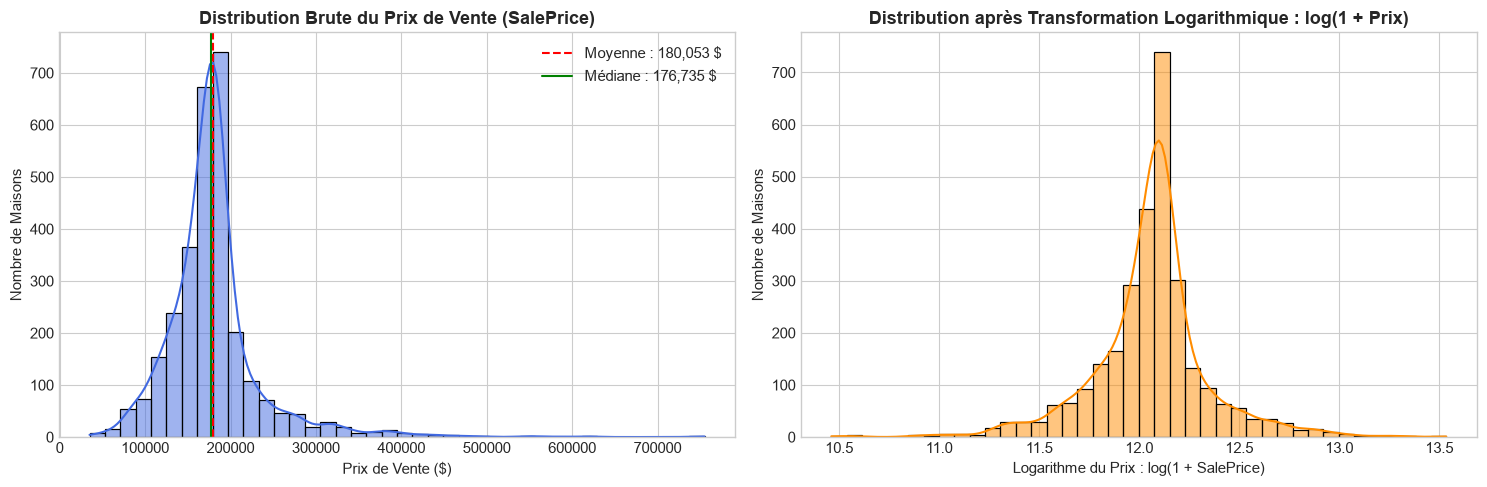

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribution brute
sns.histplot(df['SalePrice'], kde=True, color='royalblue', ax=axes[0], bins=40)
axes[0].set_title('Distribution Brute du Prix de Vente (SalePrice)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prix de Vente ($)')
axes[0].set_ylabel('Nombre de Maisons')
axes[0].axvline(prix.mean(), color='red', linestyle='--', label=f'Moyenne : {prix.mean():,.0f} $')
axes[0].axvline(prix.median(), color='green', linestyle='-', label=f'Médiane : {prix.median():,.0f} $')
axes[0].legend()

# 2. Distribution Logarithmique
sns.histplot(np.log1p(df['SalePrice']), kde=True, color='darkorange', ax=axes[1], bins=40)
axes[1].set_title('Distribution après Transformation Logarithmique : log(1 + Prix)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Logarithme du Prix : log(1 + SalePrice)')
axes[1].set_ylabel('Nombre de Maisons')

plt.tight_layout()
plt.show()


## 4. Les Visualisations Essentielles pour Comprendre le Dataset

Pour comprendre comment le prix est fixé, examinons les facteurs les plus influents : les corrélations, la surface habitable, la qualité générale, les quartiers et l'âge de construction.

---

### Graphique 2 : Les 15 Caractéristiques Numériques les Plus Liées au Prix
Ce graphique classe les variables selon la force de leur lien (la corrélation) avec le prix de vente :
- Une valeur proche de 1 indique que plus la caractéristique augmente, plus le prix est élevé.
- Les facteurs dominants sont : la **qualité globale (`OverallQual`)**, la **surface habitable (`GrLivArea`)**, la **capacité du garage (`GarageCars` / `GarageArea`)** et la **surface du sous-sol (`TotalBsmtSF`)**.


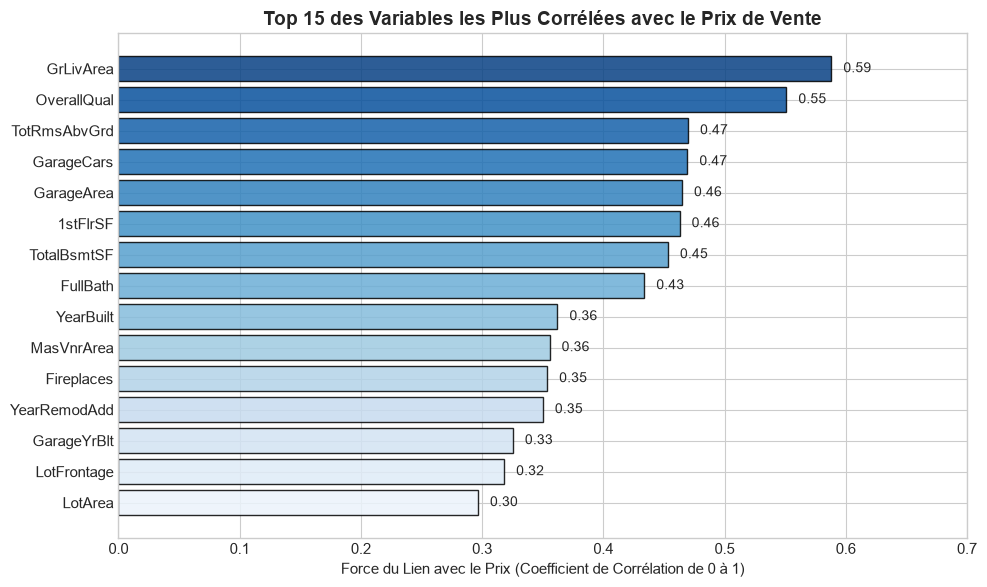

In [16]:
# Calcul des corrélations numériques avec SalePrice
cols_num = df.select_dtypes(include=[np.number]).columns
correlations = df[cols_num].corr()['SalePrice'].sort_values(ascending=False)

# Sélection des 15 meilleures (hors SalePrice elle-même)
top_corr = correlations.iloc[1:16]

plt.figure(figsize=(10, 6))
palette = sns.color_palette("Blues_r", len(top_corr))
bars = plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=palette[::-1], edgecolor='black', alpha=0.85)
plt.title('Top 15 des Variables les Plus Corrélées avec le Prix de Vente', fontsize=14, fontweight='bold')
plt.xlabel('Force du Lien avec le Prix (Coefficient de Corrélation de 0 à 1)')

# Ajout des valeurs au bout des barres
for bar in bars:
    largeur = bar.get_width()
    plt.text(largeur + 0.01, bar.get_y() + bar.get_height()/2, f"{largeur:.2f}", va='center', fontsize=10)

plt.xlim(0, 0.7)
plt.tight_layout()
plt.show()


### Graphique 3 : Relation Prix vs Surface Habitable (`GrLivArea`) & Détection des Anomalies
La surface habitable hors sous-sol est le prédicteur spatial n°1 du prix.
Remarquez :
- La tendance générale est clairement haussière : plus la maison est spacieuse, plus elle est chère.
- **Deux anomalies remarquables (Outliers)** : Deux maisons ont plus de 4 500 pieds carrés de surface mais se sont vendues à des prix très bas (moins de 200 000 $). Ce sont des ventes partielles ou atypiques bien connues dans ce jeu de données qu'il est bon d'identifier.


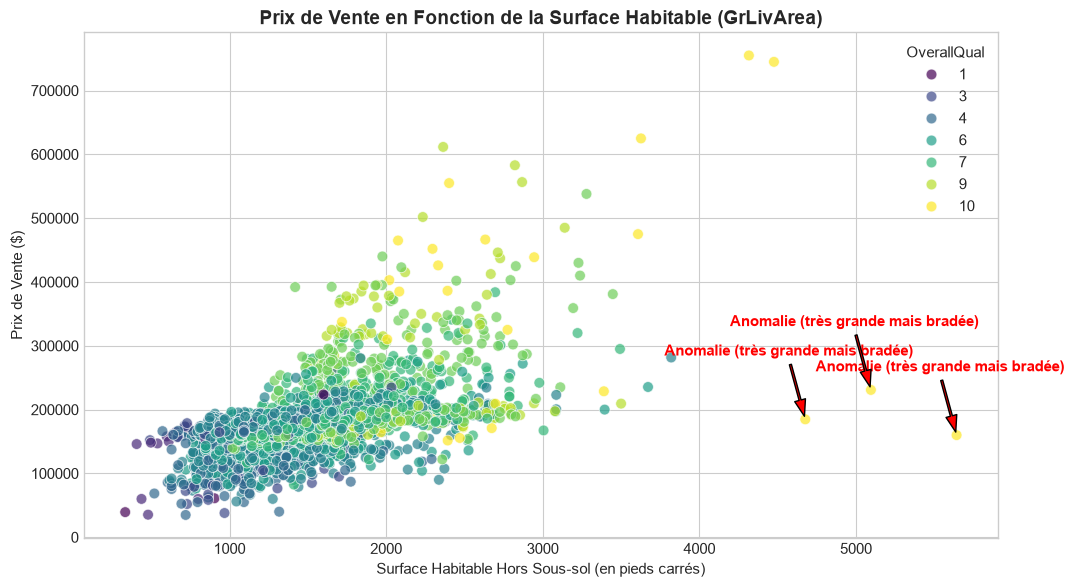

In [17]:
plt.figure(figsize=(11, 6))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', hue='OverallQual', palette='viridis', alpha=0.7, s=60)
plt.title('Prix de Vente en Fonction de la Surface Habitable (GrLivArea)', fontsize=14, fontweight='bold')
plt.xlabel('Surface Habitable Hors Sous-sol (en pieds carrés)')
plt.ylabel('Prix de Vente ($)')

# Mise en évidence des deux anomalies majeures (> 4000 sq ft et < 300 000 $)
anomalies = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
for _, row in anomalies.iterrows():
    plt.annotate('Anomalie (très grande mais bradée)', 
                 xy=(row['GrLivArea'], row['SalePrice']), 
                 xytext=(row['GrLivArea'] - 900, row['SalePrice'] + 100000),
                 arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
                 fontweight='bold', color='red')

plt.tight_layout()
plt.show()


### Graphique 4 : L'Impact de la Qualité Globale (`OverallQual`)
La note `OverallQual` va de 1 (très mauvaise) à 10 (très excellente).
Ce graphique en boîtes à moustaches (*Boxplot*) montre à quel point cette note détermine la valeur marchande d'un logement. Une maison notée 9 ou 10 vaut en moyenne 3 à 4 fois plus cher qu'une maison notée 4 ou 5.


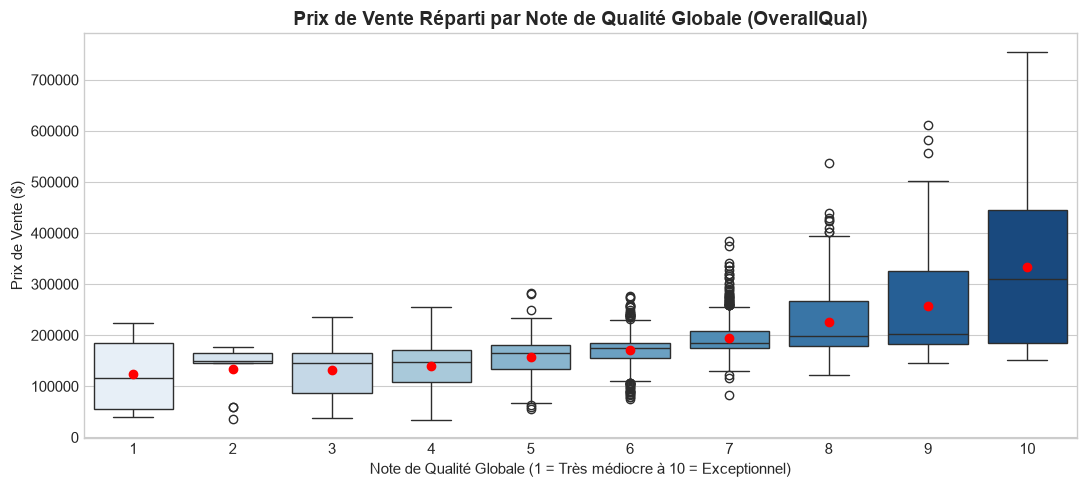

In [18]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x='OverallQual', y='SalePrice', palette='Blues', showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"red"})
plt.title('Prix de Vente Réparti par Note de Qualité Globale (OverallQual)', fontsize=14, fontweight='bold')
plt.xlabel('Note de Qualité Globale (1 = Très médiocre à 10 = Exceptionnel)')
plt.ylabel('Prix de Vente ($)')
plt.tight_layout()
plt.show()


### Graphique 5 : Le Rôle Clé du Quartier (`Neighborhood`)
En immobilier, l'emplacement est primordial. Ce graphique classe les **25 quartiers de la ville d'Ames** du moins cher au plus cher selon le prix médian de vente :
- Les quartiers comme **Meadow Village**, **IDOTRR** et **Briardale** ont des prix médians situés autour de 90 000 $ à 110 000 $.
- Les quartiers haut de gamme comme **Northridge Heights (NridgHt)**, **Stone Brook (StoneBr)** et **Northridge (NoRidge)** dépassent un prix médian de 300 000 $.


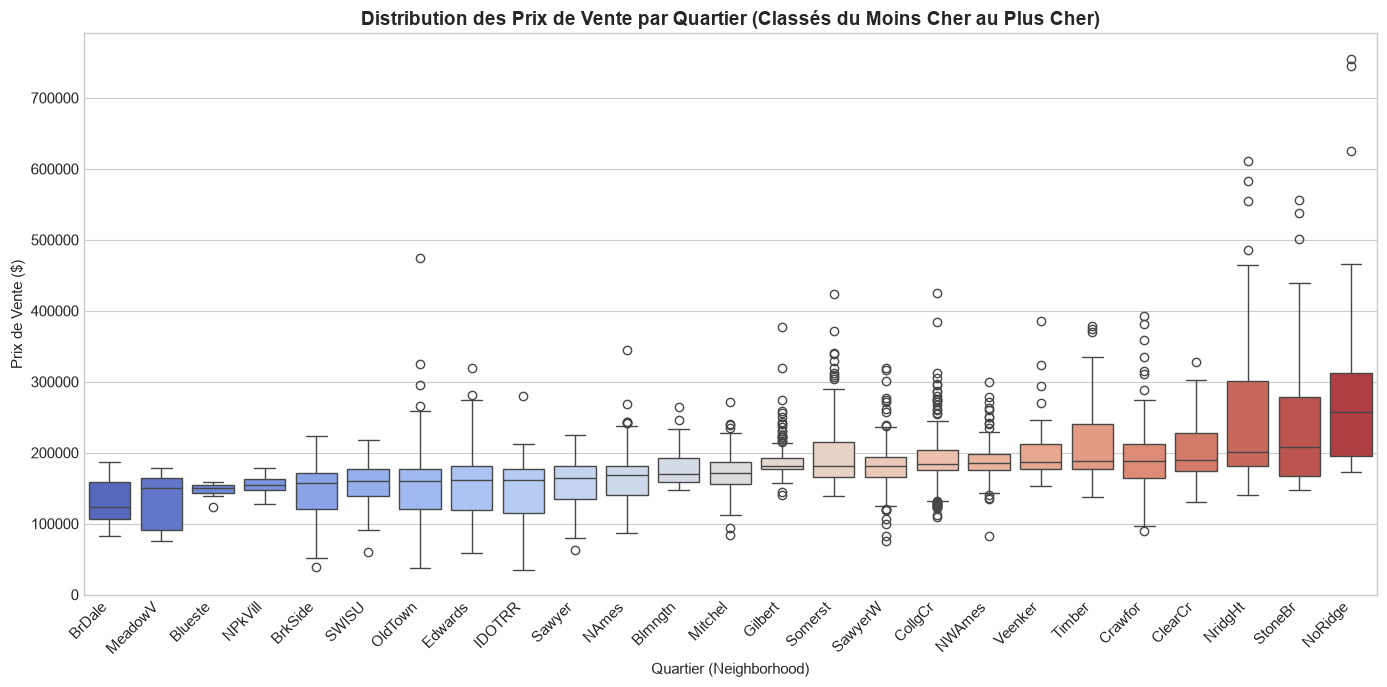

In [20]:
# Calcul du prix médian par quartier pour trier l'affichage
ordre_quartiers = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index

plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=ordre_quartiers, palette='coolwarm')
plt.title('Distribution des Prix de Vente par Quartier (Classés du Moins Cher au Plus Cher)', fontsize=14, fontweight='bold')
plt.xlabel('Quartier (Neighborhood)')
plt.ylabel('Prix de Vente ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Graphique 6 : L'Année de Construction (`YearBuilt`) et les Rénovations
Les maisons récentes (construites après l'an 2000) se vendent nettement plus cher que les maisons anciennes, avec toutefois une prime pour les maisons anciennes ayant bénéficié de rénovations majeures.


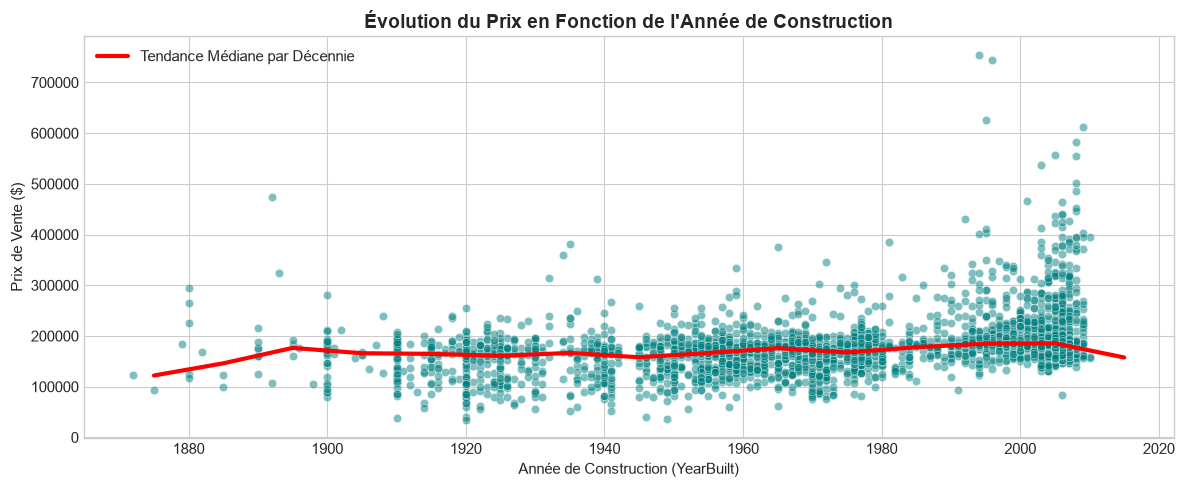

In [19]:
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x='YearBuilt', y='SalePrice', alpha=0.5, color='teal')
# Ajout d'une ligne de tendance médiane par décennie
df['Decennie'] = (df['YearBuilt'] // 10) * 10
median_decennie = df.groupby('Decennie')['SalePrice'].median()
plt.plot(median_decennie.index + 5, median_decennie.values, color='red', linewidth=3, label='Tendance Médiane par Décennie')

plt.title('Évolution du Prix en Fonction de l\'Année de Construction', fontsize=14, fontweight='bold')
plt.xlabel('Année de Construction (YearBuilt)')
plt.ylabel('Prix de Vente ($)')
plt.legend()
plt.tight_layout()
plt.show()


## 5. Diagnostic Exhaustif de Toutes les Valeurs Manquantes

Vous avez pris la décision judicieuse de **conserver l'intégralité des colonnes** pour donner au modèle toutes les informations possibles. Pour cela, il est indispensable de comprendre la nature exacte de chaque valeur manquante.

Dans ce jeu de données, les cases vides se divisent en deux catégories bien distinctes :
1. **Les fausses valeurs manquantes (Absence d'équipement)** : La documentation `data_description.txt` indique clairement que pour `PoolQC`, la valeur `NA` signifie simplement *"Pas de piscine"*. Pour `GarageType`, `NA` signifie *"Pas de garage"*. Pour `BsmtQual`, `NA` signifie *"Pas de sous-sol"*. Ce ne sont pas des données perdues, c'est une information précieuse !
2. **Les réelles valeurs manquantes** : Des données omises lors de la saisie (comme `LotFrontage` où la façade de rue n'a pas été mesurée, ou `Electrical` où le type de panneau n'est pas renseigné pour une seule maison).

Voyons la liste complète des 34 colonnes qui contiennent au moins une valeur nulle.


In [21]:
# Identification de toutes les colonnes contenant des valeurs nulles
null_counts = df.isnull().sum()
null_cols = null_counts[null_counts > 0].sort_values(ascending=False)
null_pct = (null_cols / len(df)) * 100

df_nulls = pd.DataFrame({
    'Nb Manquants': null_cols,
    'Pourcentage (%)': null_pct.round(2),
    'Type': df[null_cols.index].dtypes
})

print(f"Total de colonnes contenant des valeurs manquantes : {len(df_nulls)} sur 81.")
df_nulls


Total de colonnes contenant des valeurs manquantes : 34 sur 81.


,Nb Manquants,Pourcentage (%),Type
PoolQC,2909,99.66,str
MiscFeature,2814,96.40,str
Alley,2721,93.22,str
Fence,2348,80.44,str
MasVnrType,1766,60.50,str
FireplaceQu,1420,48.65,str
LotFrontage,486,16.65,float64
GarageQual,159,5.45,str
GarageYrBlt,159,5.45,float64
GarageCond,159,5.45,str


### Graphique 7 : Visualisation des 34 Colonnes avec Valeurs Manquantes
Ce graphique présente en un coup d'œil les colonnes les plus touchées.
On constate immédiatement que les colonnes ayant plus de 80% de cases vides sont toutes des équipements optionnels (`PoolQC` = piscine, `MiscFeature` = cabane, `Alley` = allée, `Fence` = clôture).


In [ ]:
plt.figure(figsize=(12, 8))
y_pos = range(len(df_nulls))
palette = sns.color_palette("rocket", len(df_nulls))
bars = plt.barh(y_pos, df_nulls['Pourcentage (%)'][::-1], color=palette, edgecolor='black')

plt.yticks(y_pos, df_nulls.index[::-1], fontsize=10)
plt.title('Pourcentage de Valeurs Manquantes par Colonne (Total 34 Colonnes)', fontsize=14, fontweight='bold')
plt.xlabel('Pourcentage de Valeurs Manquantes (%)')

for bar in bars:
    largeur = bar.get_width()
    if largeur > 1:
        plt.text(largeur + 0.5, bar.get_y() + bar.get_height()/2, f"{largeur:.1f}%", va='center', fontsize=9)

plt.xlim(0, 105)
plt.tight_layout()
plt.show()


## 6. Stratégie et Code de Nettoyage / Imputation Complète

Voici le plan de traitement rigoureux pour **remplacer et corriger 100 % des valeurs nulles** sans supprimer aucune colonne :

### A. Équipements Optionnels Catégoriels $\rightarrow$ Remplacer par `'None'` (Pas d'équipement)
Ces colonnes représentent des équipements que la maison ne possède pas :
- **Piscine** : `PoolQC` $\rightarrow$ `'None'`
- **Aménagements divers** : `MiscFeature` $\rightarrow$ `'None'`
- **Allée** : `Alley` $\rightarrow$ `'None'`
- **Clôture** : `Fence` $\rightarrow$ `'None'`
- **Cheminée** : `FireplaceQu` $\rightarrow$ `'None'`
- **Garage** : `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond` $\rightarrow$ `'None'`
- **Sous-sol** : `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` $\rightarrow$ `'None'`
- **Revêtement maçonnerie** : `MasVnrType` $\rightarrow$ `'None'`

### B. Équipements Optionnels Numériques $\rightarrow$ Remplacer par `0`
Si une maison n'a pas de sous-sol ou pas de garage, la surface ou le nombre de pièces correspondant vaut exactement 0 :
- **Garage** : `GarageCars`, `GarageArea` $\rightarrow$ `0`
- **Sous-sol** : `BsmtFinSF1`, `BsmtFinSF2`, `BsmtUnfSF`, `TotalBsmtSF`, `BsmtFullBath`, `BsmtHalfBath` $\rightarrow$ `0`
- **Revêtement maçonnerie** : `MasVnrArea` $\rightarrow$ `0`

### C. Imputations Contextuelles
- **`LotFrontage` (Façade sur rue)** : Les maisons d'un même quartier ont généralement des façades similaires. Nous remplaçons les valeurs manquantes par la **médiane de la façade du quartier concerné** (`Neighborhood`).
- **`GarageYrBlt` (Année de construction du garage)** : Si une maison n'a pas de garage, on peut affecter l'année de construction de la maison `YearBuilt` ou 0.
- **Variables rares manquantes (1 à 4 valeurs manquantes)** : `MSZoning`, `Utilities`, `Exterior1st`, `Exterior2nd`, `Electrical`, `KitchenQual`, `Functional`, `SaleType` $\rightarrow$ Remplacer par la valeur la plus fréquente (**le Mode**).

Exécutons ce traitement complet ci-dessous :


In [ ]:
# Création d'une copie propre des données
df_clean = df.copy()

# Supprimer uniquement la colonne technique Id qui n'est pas une mesure de la maison
if 'Id' in df_clean.columns:
    df_clean.drop(columns=['Id'], inplace=True)
if 'Decennie' in df_clean.columns:
    df_clean.drop(columns=['Decennie'], inplace=True)

# 1. Traitement des catégories où NA = Absence d'équipement (remplacement par 'None')
cols_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cols_none:
    df_clean[col] = df_clean[col].fillna('None')

# 2. Traitement des valeurs numériques où NA = 0 (absence de surface ou de pièces)
cols_zero = [
    'GarageCars', 'GarageArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath',
    'MasVnrArea'
]
for col in cols_zero:
    df_clean[col] = df_clean[col].fillna(0.0)

# 3. Traitement de LotFrontage par la médiane de chaque quartier
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
# Au cas où un quartier entier n'aurait pas de valeur (sécurité)
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())

# 4. Traitement de GarageYrBlt : si pas de garage, on utilise l'année de construction de la maison
df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(df_clean['YearBuilt'])

# 5. Traitement des rares variables catégorielles avec oublis de saisie (Mode = valeur la plus courante)
cols_mode = [
    'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 
    'Electrical', 'KitchenQual', 'Functional', 'SaleType'
]
for col in cols_mode:
    valeur_la_plus_frequente = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(valeur_la_plus_frequente)

# Vérification finale : reste-t-il la moindre valeur manquante ?
nb_restants = df_clean.isnull().sum().sum()
print(f"Vérification finale : Il reste exactement {nb_restants} valeur manquante dans tout le jeu de données !")
print(f"Le jeu de données nettoyé contient {df_clean.shape[0]} lignes et {df_clean.shape[1]} colonnes prêtes pour la modélisation.")


## 7. Préparation des Données pour les Modèles (Encodage des Variables)

Les modèles d'apprentissage automatique (Régression Linéaire, Random Forest, XGBoost) ne peuvent calculer qu'à partir de valeurs chiffrées.
Puisque nous avons conservé toutes les colonnes, voici la manière la plus performante de convertir les textes en nombres :

### A. Les Variables Ordinales (Notes qualitatives)
Ces variables expriment un ordre de mérite (Mauvais < Moyen < Bon < Excellent). On leur attribue une note de 0 à 5 :
- `'None'`: 0
- `'Po'` (Poor) : 1
- `'Fa'` (Fair) : 2
- `'TA'` (Typical/Average) : 3
- `'Gd'` (Good) : 4
- `'Ex'` (Excellent) : 5

### B. Les Variables Nominales (Quartiers, Styles, Matériaux)
Ces variables n'ont pas d'ordre hiérarchique (par exemple, le quartier *College Creek* n'est pas mathématiquement "supérieur" à *Old Town*). On utilise l'encodage disjonctif (**One-Hot Encoding** / `pd.get_dummies` ou `OneHotEncoder`).

Voyons un aperçu de cette conversion :


In [ ]:
# Définition de l'échelle ordinale standard
echelle_qualite = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

cols_ordinales_qualite = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
                          'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in cols_ordinales_qualite:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(echelle_qualite).fillna(0).astype(int)

print("Exemple de conversion ordinale réussie pour ExterQual et KitchenQual :")
df_clean[['ExterQual', 'KitchenQual']].head(5)


## 8. Synthèse et Prochaines Étapes (Étapes 5 à 9 du Projet)

Grâce à cette analyse complète :
1. **Chaque colonne est comprise** et documentée dans notre dictionnaire de données.
2. **Toutes les valeurs manquantes sont imputées et corrigées**, permettant de conserver les 80 colonnes prédictives.
3. **Les relations majeures et la distribution de la cible ont été visualisées** de façon claire et sans notations mathématiques hermétiques.

### Ce qui nous attend dans les étapes suivantes :
- **Étape 5 — Validation croisée (K-Fold) et Optimisation (GridSearchCV)** :
  - Découper nos données en 5 ou 10 blocs (*folds*) pour tester la robustesse des modèles.
  - Rechercher les meilleurs réglages d'hyperparamètres (régularisation pour Ridge/Lasso, profondeur pour les arbres de décision et Random Forest).
- **Étape 6 — Évaluation et Comparaison** :
  - Comparer les modèles avec les métriques **MAE** (erreur moyenne absolue en $), **RMSE** (racine de l'erreur quadratique moyenne) et **R²** (pourcentage de variance expliquée).
  - Graphiques Prix Réel vs Prix Prédit et analyse des résidus.
- **Étape 7 — Interprétation du Modèle** :
  - Extraire l'importance des variables pour confirmer les intuitions découvertes lors de cette exploration.
- **Étape 8 — Application Streamlit** :
  - Interface interactive permettant à un utilisateur d'entrer les caractéristiques d'un logement pour obtenir son prix estimé en temps réel.
- **Étape 9 — Conteneurisation Docker** :
  - Création du `Dockerfile` et des commandes pour déployer l'application partout facilement.
